In [10]:
!pip install -q yfinance --upgrade

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [12]:
sp500 = yf.download("^GSPC", start="2000-01-01", end="2024-12-31")

if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

print(sp500.columns.tolist())
print(sp500.shape)
sp500.head()

[*********************100%***********************]  1 of 1 completed

['Close', 'High', 'Low', 'Open', 'Volume']
(6288, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [13]:
sp500 = sp500[["Close", "High", "Low", "Volume"]]
sp500.dropna(inplace=True)

print(sp500.shape)
sp500.head()

(6288, 4)


Price,Close,High,Low,Volume
Date,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1225200000


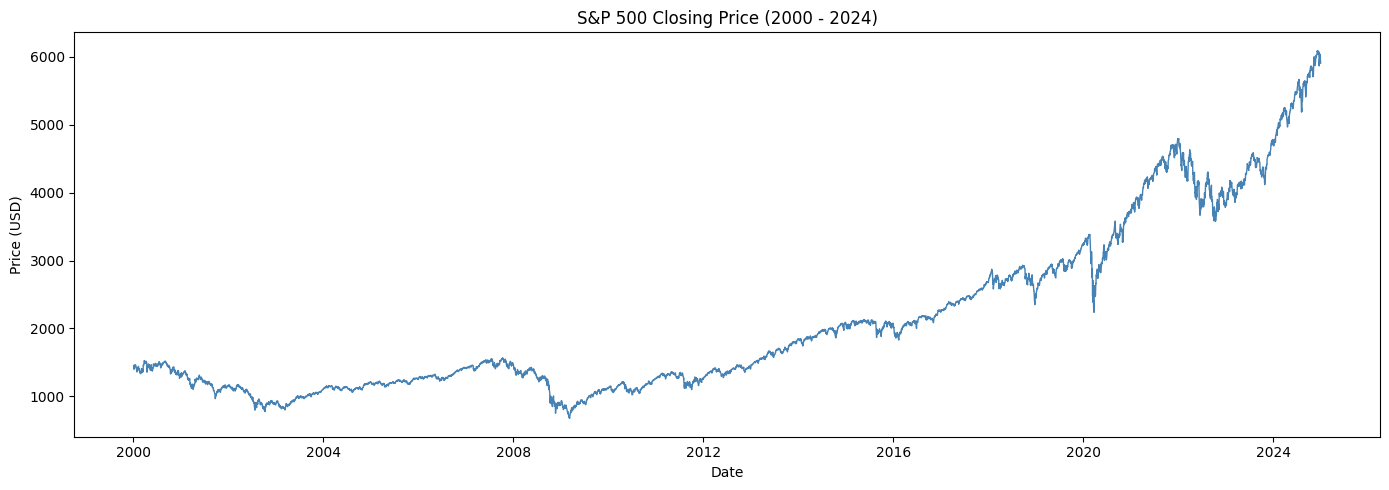

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(sp500["Close"], color="steelblue", linewidth=1)
plt.title("S&P 500 Closing Price (2000 - 2024)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

In [15]:
sp500["Close_Lag1"] = sp500["Close"].shift(1)
sp500["Close_Lag5"] = sp500["Close"].shift(5)

sp500["Close_MA10_Ratio"] = sp500["Close"] / sp500["Close"].rolling(10).mean()
sp500["Close_MA50_Ratio"] = sp500["Close"] / sp500["Close"].rolling(50).mean()
sp500["Close_MA200_Ratio"] = sp500["Close"] / sp500["Close"].rolling(200).mean()

delta = sp500["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
sp500["RSI"] = 100 - (100 / (1 + gain / loss))

sp500["Daily_Return"] = sp500["Close"].pct_change()
sp500["Return_5d"] = sp500["Close"].pct_change(5)
sp500["Return_21d"] = sp500["Close"].pct_change(21)

sp500["Volatility_10d"] = sp500["Daily_Return"].rolling(10).std()
sp500["Volatility_21d"] = sp500["Daily_Return"].rolling(21).std()

sp500["Momentum_10d"] = sp500["Close"] - sp500["Close"].shift(10)
sp500["Momentum_21d"] = sp500["Close"] - sp500["Close"].shift(21)

# Volume features
sp500["Volume_MA10_Ratio"] = sp500["Volume"] / sp500["Volume"].rolling(10).mean()
sp500["Volume_MA50_Ratio"] = sp500["Volume"] / sp500["Volume"].rolling(50).mean()

# Day of week (0=Monday, 4=Friday)
sp500["DayOfWeek"] = sp500.index.dayofweek

# Upper and Lower Shadow
sp500["Upper_Shadow"] = sp500["High"] - sp500["Close"]
sp500["Lower_Shadow"] = sp500["Close"] - sp500["Low"]

sp500["Target"] = (sp500["Close"].shift(-1) > sp500["Close"]).astype(int)

sp500.dropna(inplace=True)
print(sp500.shape)
sp500.head()

(6089, 23)


Price,Close,High,Low,Volume,Close_Lag1,Close_Lag5,Close_MA10_Ratio,Close_MA50_Ratio,Close_MA200_Ratio,RSI,...,Volatility_10d,Volatility_21d,Momentum_10d,Momentum_21d,Volume_MA10_Ratio,Volume_MA50_Ratio,DayOfWeek,Upper_Shadow,Lower_Shadow,Target
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-16,1374.619995,1379.479980,1365.060059,1005400000,1374.170044,1402.030029,0.986221,0.940119,0.951437,38.331503,...,0.016412,0.013438,-61.609985,-91.190063,0.885214,1.012975,0,4.859985,9.559937,0
2000-10-17,1349.969971,1380.989990,1342.339966,1161500000,1374.619995,1387.020020,0.973880,0.924897,0.934716,34.640699,...,0.016972,0.013604,-76.489990,-94.540039,1.016977,1.163063,1,31.020020,7.630005,0
2000-10-18,1342.130005,1356.650024,1305.790039,1441700000,1349.969971,1364.589966,0.974707,0.921302,0.929472,24.241622,...,0.016538,0.013239,-92.189941,-117.770020,1.232707,1.430760,2,14.520020,36.339966,1
2000-10-19,1388.760010,1389.930054,1342.130005,1297900000,1342.130005,1329.780029,1.012064,0.954413,0.961809,40.462592,...,0.021053,0.015681,-47.520020,-62.579956,1.098314,1.281846,3,1.170044,46.630005,1
2000-10-20,1396.930054,1408.469971,1382.189941,1177400000,1388.760010,1374.170044,1.018913,0.960864,0.967489,42.390227,...,0.020435,0.015775,-12.059937,-52.119995,0.994048,1.157427,4,11.539917,14.740112,0


In [16]:
features = [
    "Close_Lag1", "Close_Lag5",
    "Close_MA10_Ratio", "Close_MA50_Ratio", "Close_MA200_Ratio",
    "RSI", "Daily_Return", "Return_5d", "Return_21d",
    "Volatility_10d", "Volatility_21d",
    "Momentum_10d", "Momentum_21d",
    "Volume_MA10_Ratio", "Volume_MA50_Ratio",
    "DayOfWeek", "Upper_Shadow", "Lower_Shadow"
]
X = sp500[features]
y = sp500["Target"]

In [17]:
def backtest(data, features, target, start=2500, step=250):
    all_preds = []
    for i in range(start, len(data), step):
        X_train = data[features][:i]
        y_train = data[target][:i]
        X_test = data[features][i:i+step]
        y_test = data[target][i:i+step]

        rf = RandomForestClassifier(
            n_estimators=300,
            min_samples_split=20,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42
        )
        rf.fit(X_train, y_train)

        preds = pd.DataFrame({
            "Actual": y_test,
            "Predicted": rf.predict(X_test)
        }, index=X_test.index)
        all_preds.append(preds)

    return pd.concat(all_preds)

results = backtest(sp500, features, "Target")
acc = accuracy_score(results["Actual"], results["Predicted"])
print(f"Backtested Accuracy: {acc:.4f}")

Backtested Accuracy: 0.5046


In [18]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_split": [10, 20, 50],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy: 0.5122


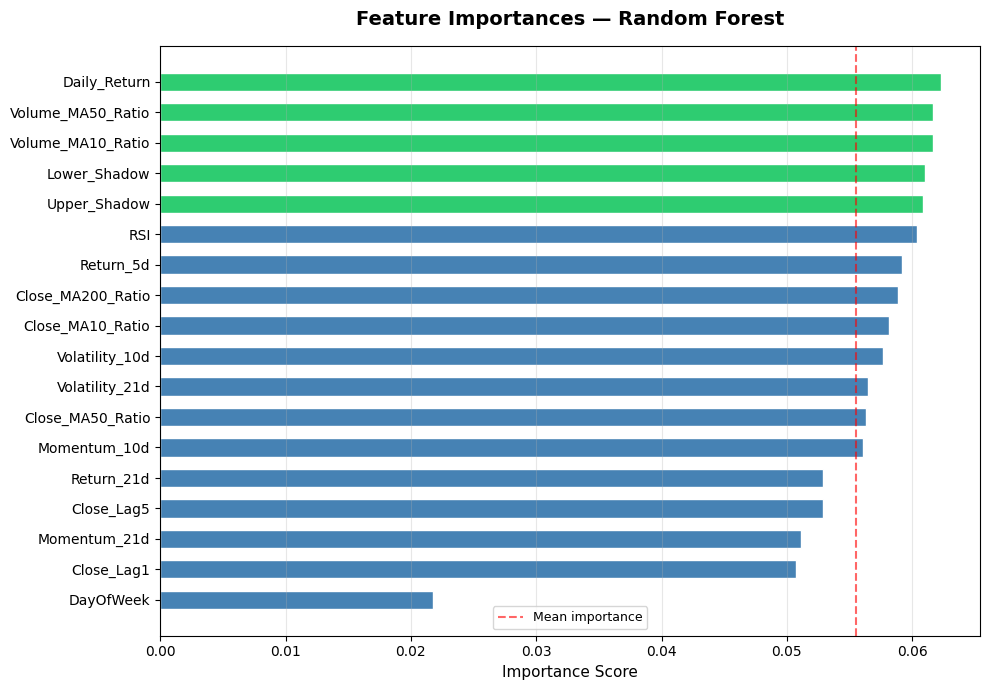

In [22]:
feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=True)

colors = ["#2ecc71" if i >= len(feat_df)-5 else "steelblue" for i in range(len(feat_df))]

plt.figure(figsize=(10, 7))
bars = plt.barh(feat_df["Feature"], feat_df["Importance"], color=colors, edgecolor="white", height=0.6)
plt.title("Feature Importances — Random Forest", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Importance Score", fontsize=11)
plt.axvline(x=feat_df["Importance"].mean(), color="red", linestyle="--", alpha=0.6, label="Mean importance")
plt.legend(fontsize=9)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

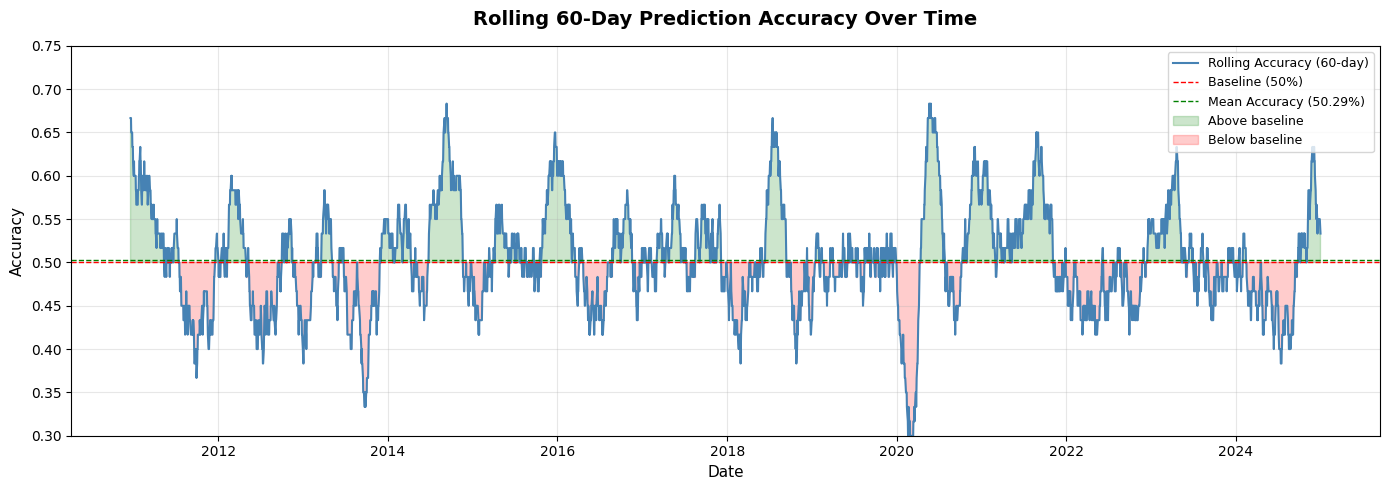

In [24]:
# Rolling 30-day accuracy — much cleaner visualization
results["Correct"] = (results["Actual"] == results["Predicted"]).astype(int)
rolling_acc = results["Correct"].rolling(window=60).mean()

plt.figure(figsize=(14, 5))
plt.plot(rolling_acc.index, rolling_acc, color="steelblue", linewidth=1.5, label="Rolling Accuracy (60-day)")
plt.axhline(y=0.5, color="red", linestyle="--", linewidth=1, label="Baseline (50%)")
plt.axhline(y=rolling_acc.mean(), color="green", linestyle="--", linewidth=1, label=f"Mean Accuracy ({rolling_acc.mean():.2%})")
plt.fill_between(rolling_acc.index, 0.5, rolling_acc, where=rolling_acc >= 0.5, alpha=0.2, color="green", label="Above baseline")
plt.fill_between(rolling_acc.index, 0.5, rolling_acc, where=rolling_acc < 0.5, alpha=0.2, color="red", label="Below baseline")
plt.title("Rolling 60-Day Prediction Accuracy Over Time", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.ylim(0.3, 0.75)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
print("=" * 50)
print("      S&P 500 Direction Prediction Summary")
print("=" * 50)
print(f"  Total Samples:          {len(sp500)}")
print(f"  Features Used:          {len(features)}")
print(f"  Backtested Accuracy:    {acc:.4f}")
print(f"  Best CV Accuracy:       {grid_search.best_score_:.4f}")
print(f"  Best Parameters:        {grid_search.best_params_}")
print("=" * 50)

      S&P 500 Direction Prediction Summary
  Total Samples:          6089
  Features Used:          18
  Backtested Accuracy:    0.5046
  Best CV Accuracy:       0.5122
  Best Parameters:        {'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
